In [1]:
! pip install --upgrade pip
! pip install pandas matplotlib seaborn openpyxl xlrd ipywidgets

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------- ----- 1.6/1.8 MB 20.8 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 19.9 MB/s  0:00:00



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Users\Jacob\reddit-data-collector-v2\.venv\scripts\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
%matplotlib inline
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def to_bool_like(x):
    if isinstance(x, bool):
        return x
    if pd.isna(x):
        return False
    return str(x).strip().lower() in {"true", "1", "yes", "y", "t"}
def split_personas(value):
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    return [part.strip() for part in text.split(',') if part.strip()]

def split_multi(value):
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    return [part.strip() for part in text.split(',') if part.strip()]

In [13]:
# Load the data
p = Path('final_labelling_with_info_and_author_mismatch.xlsx')
df = pd.read_excel(p)

df = df[df['irrelevant'] != True].reset_index(drop=True)
print('Data shape:', df.shape)
df.head()


Data shape: (759, 17)


,file_name,id,timestamp,author,subreddit,title,content,post_comment,persona,relationship,engagement,irrelevant,sentiment,confidence,upvotes,downvotes,permalink
0,43_11.txt,mr9l2cf,2025-05-08 16:06:00,ThePorko,cybersecurity,NaN,Better question is do they have the $ to secur...,Comment,IT/security professional,Unaffected,Sarcasm/humor,False,NEGATIVE,0.999201,2.0,0.0,https://reddit.com/r/cybersecurity/comments/1k...
1,43_18.txt,mra4uf1,2025-05-08 17:41:00,hecalopter,cybersecurity,NaN,I'd never realized how bad it was until we loo...,Comment,EdTech developer/employee,Unaffected,Information/News-sharing,False,NEGATIVE,0.998241,2.0,0.0,https://reddit.com/r/cybersecurity/comments/1k...
2,10_33.txt,m6g349t,2025-01-10 18:46:00,shredu2,raleigh,NaN,The company deactivated the compromised accoun...,Comment,Privacy/policy advocate,Unaffected,"Blame attribution, Frustration/Anger",False,NEGATIVE,0.999243,1.0,0.0,https://reddit.com/r/raleigh/comments/1hxqotl/...
3,25_17.txt,m8ui1zr,2025-01-24 03:04:00,PersonOfValue,Sacramento,NaN,Similar experience. Private equity meets educa...,Comment,EdTech developer/employee,Unaffected,"Blame attribution, Frustration/Anger",False,NEGATIVE,0.999798,17.0,0.0,https://reddit.com/r/Sacramento/comments/1i8h0...
4,60_12.txt,m9qeowa,2025-01-29 00:02:00,the_house_hippo,newfoundland,NaN,Can someone please explain why people who have...,Comment,Student,Affected,"Information-seeking, Factual confusion/clarifi...",False,NEGATIVE,0.999485,16.0,0.0,https://reddit.com/r/newfoundland/comments/1ic...


In [14]:
# Prepare output directory
out_dir = Path('analysis_outputs')
out_dir.mkdir(parents=True, exist_ok=True)

# Clean string columns a bit
for col in [c for c in df.columns if df[c].dtype == object]:
    df[col] = df[col].astype(str).str.strip()

# Skip rows marked irrelevant (unless user opts in)
if 'irrelevant' in df.columns:
    irrelevant_mask = df['irrelevant'].apply(to_bool_like)
    skipped = int(irrelevant_mask.sum())
    print(f"Rows flagged irrelevant (will be skipped by default): {skipped}")
    df_non_irrelevant = df[~irrelevant_mask].copy().reset_index(drop=True)
else:
    print("No 'irrelevant' column found; using full dataframe")
    df_non_irrelevant = df.copy().reset_index(drop=True)

print('Original rows:', len(df), 'Rows after skipping irrelevant:', len(df_non_irrelevant))

# Explode comma-separated persona labels for persona-specific summaries and charts
persona_analysis_df = df_non_irrelevant.copy()
if 'persona' in persona_analysis_df.columns:
    persona_analysis_df['persona'] = persona_analysis_df['persona'].apply(split_personas)
    persona_analysis_df = persona_analysis_df.explode('persona').reset_index(drop=True)
    persona_analysis_df['persona'] = persona_analysis_df['persona'].fillna('').astype(str).str.strip()
    persona_analysis_df = persona_analysis_df[persona_analysis_df['persona'] != ''].reset_index(drop=True)
else:
    persona_analysis_df = df_non_irrelevant.copy()

# Explode comma-separated engagement labels for engagement-specific summaries and charts
engagement_analysis_df = df_non_irrelevant.copy()
if 'engagement' in engagement_analysis_df.columns:
    engagement_analysis_df['engagement'] = engagement_analysis_df['engagement'].apply(split_multi)
    engagement_analysis_df = engagement_analysis_df.explode('engagement').reset_index(drop=True)
    engagement_analysis_df['engagement'] = engagement_analysis_df['engagement'].fillna('').astype(str).str.strip()
    engagement_analysis_df = engagement_analysis_df[engagement_analysis_df['engagement'] != ''].reset_index(drop=True)
else:
    engagement_analysis_df = df_non_irrelevant.copy()

# Build persona x engagement frame with exploded labels on both axes
persona_engagement_df = df_non_irrelevant.copy()
if ('persona' in persona_engagement_df.columns) and ('engagement' in persona_engagement_df.columns):
    persona_engagement_df['persona'] = persona_engagement_df['persona'].apply(split_personas)
    persona_engagement_df['engagement'] = persona_engagement_df['engagement'].apply(split_multi)
    persona_engagement_df = persona_engagement_df.explode('persona').explode('engagement').reset_index(drop=True)
    persona_engagement_df['persona'] = persona_engagement_df['persona'].fillna('').astype(str).str.strip()
    persona_engagement_df['engagement'] = persona_engagement_df['engagement'].fillna('').astype(str).str.strip()
    persona_engagement_df = persona_engagement_df[
        (persona_engagement_df['persona'] != '') & (persona_engagement_df['engagement'] != '')
    ].reset_index(drop=True)
else:
    persona_engagement_df = df_non_irrelevant.copy()

# Provide interactive filtering and preview (uses ipywidgets)
try:
    from ipywidgets import widgets, HBox, VBox, Output
    from IPython.display import display, clear_output
    have_widgets = True
except Exception:
    have_widgets = False

if not have_widgets:
    print("ipywidgets not available. To enable interactive filtering install ipywidgets (pip install ipywidgets) and enable in Jupyter.")
else:
    # base dataframe used for filtering (respects the "skip irrelevant" default)
    include_irrelevant_cb = widgets.Checkbox(value=False, description='Include irrelevant rows')
    cols = list(df.columns)
    col_selector = widgets.Dropdown(options=cols, description='Column:')
    value_text = widgets.Text(description='Value:')
    case_cb = widgets.Checkbox(value=True, description='case-insensitive (contains for strings)')
    head_count = 1000
    out = Output()

    def apply_filter(_=None):
        with out:
            clear_output(wait=True)
            base_df = df if include_irrelevant_cb.value else df_non_irrelevant
            col = col_selector.value
            val = value_text.value
            if val == '':
                res = base_df.head(head_count)
                print(f"Showing top {head_count} rows (no filter applied).")
                display(res)
                return
            series = base_df[col] if col in base_df.columns else pd.Series([], dtype=object)
            # string-like columns: do contains search
            if pd.api.types.is_string_dtype(series) or series.dtype == object:
                if case_cb.value:
                    mask = series.fillna('').str.contains(val, case=False, na=False)
                else:
                    mask = series.fillna('').str.contains(val, case=True, na=False)
            else:
                # try numeric equality, fallback to string contains
                try:
                    num = float(val)
                    mask = pd.to_numeric(series, errors='coerce') == num
                except Exception:
                    mask = series.astype(str).str.contains(val, case=case_cb.value, na=False)
            filtered = base_df[mask] if len(series) else base_df.iloc[0:0]
            print(f"Filter: {col} contains '{val}' -> {len(filtered)} rows")
            display(filtered.head(head_count))

    apply_button = widgets.Button(description='Apply filter')
    apply_button.on_click(apply_filter)

    controls = HBox([include_irrelevant_cb, col_selector, value_text, case_cb, apply_button])
    display(VBox([controls, out]))

    # show initial preview (non-irrelevant head)
    #display(df_non_irrelevant.head(1000))


Rows flagged irrelevant (will be skipped by default): 0
Original rows: 759 Rows after skipping irrelevant: 759


In [15]:
# Persona counts
if 'persona' in persona_analysis_df.columns:
    persona_counts = persona_analysis_df['persona'].fillna('(blank)').value_counts(dropna=False)
    display(persona_counts.head(20))
    persona_counts.to_csv(out_dir / 'persona_counts.csv', header=['count'])

# Relationship counts
if 'relationship' in df.columns:
    rel_counts = df['relationship'].fillna('(blank)').value_counts(dropna=False)
    display(rel_counts.head(20))
    rel_counts.to_csv(out_dir / 'relationship_counts.csv', header=['count'])

# Engagement counts
if 'engagement' in engagement_analysis_df.columns:
    eng_counts = engagement_analysis_df['engagement'].fillna('(blank)').value_counts(dropna=False)
    display(eng_counts.head(20))
    eng_counts.to_csv(out_dir / 'engagement_counts.csv', header=['count'])

# Irrelevant summary
if 'irrelevant' in df.columns:
    irrelevant_bool = df['irrelevant'].apply(to_bool_like)
    irrelevant_summary = pd.Series({'irrelevant_true': int(irrelevant_bool.sum()), 'irrelevant_false': int((~irrelevant_bool).sum())})
    display(irrelevant_summary)
    irrelevant_summary.to_csv(out_dir / 'irrelevant_summary.csv', header=['count'])

# Persona x Relationship crosstab
if ('persona' in persona_analysis_df.columns) and ('relationship' in persona_analysis_df.columns):
    ct = pd.crosstab(persona_analysis_df['persona'].fillna('(blank)'), persona_analysis_df['relationship'].fillna('(blank)'))
    display(ct)
    ct.to_csv(out_dir / 'persona_relationship_crosstab.csv')

# Author consistency
if 'author' in df_non_irrelevant.columns:
    tmp = df_non_irrelevant.copy()
    for col in ['author', 'relationship']:
        if col in tmp.columns:
            tmp[col] = tmp[col].fillna('').astype(str).str.strip()

    def non_empty_unique_count(series):
        vals = [v for v in series if v != '']
        return len(set(vals))

    rows = []
    for author, grp in tmp[tmp['author'] != ''].groupby('author'):
        persona_vals = set()
        if 'persona' in grp.columns:
            for value in grp['persona']:
                persona_vals.update(split_personas(value))
        relationship_vals = set(v for v in grp['relationship'] if v != '') if 'relationship' in grp.columns else set()
        rows.append({
            'author': author,
            'persona_unique': len(persona_vals),
            'relationship_unique': len(relationship_vals),
            'row_count': len(grp),
        })

    author_consistency = pd.DataFrame(rows)
    display(author_consistency.sort_values(['persona_unique','relationship_unique','row_count'], ascending=False).head(20))
    author_consistency.to_csv(out_dir / 'author_persona_relationship_consistency.csv', index=False)

print('Saved CSV summaries to', out_dir)


persona
School IT/admin              417
General observser            100
Parent/guardian               75
Teacher/educator              66
IT/security professional      62
Privacy/policy advocate       18
Student                       18
Reporter/Media People         14
EdTech developer/employee     10
Name: count, dtype: int64

relationship
Affected             333
Unaffected           283
Possibly affected    113
Unsure/Unclear        30
Name: count, dtype: int64

engagement
Information/News-sharing           403
Frustration/Anger                  119
Factual confusion/clarification    111
Information-seeking                102
Advice-giving                       95
Speculation                         78
Blame attribution                   71
Express agreement                   56
Sarcasm/humor                       47
Technical explanation               45
Express Concern                     39
Misc.                               31
Express wish                        29
Surprise                            26
Express disagreement                21
Advice-seeking                      19
Relief                               6
Express gratitude                    3
Name: count, dtype: int64

irrelevant_true       0
irrelevant_false    759
dtype: int64

relationship,Affected,Possibly affected,Unaffected,Unsure/Unclear
persona,,,,
EdTech developer/employee,1,0,9,0
General observser,4,10,79,7
IT/security professional,0,0,61,1
Parent/guardian,67,5,3,0
Privacy/policy advocate,0,0,16,2
Reporter/Media People,0,0,14,0
School IT/admin,225,81,92,19
Student,12,5,1,0
Teacher/educator,43,12,10,1


,author,persona_unique,relationship_unique,row_count
403,vawlk,2,1,14
393,theatreeducator,2,1,2
13,AppealSignificant764,2,1,1
25,CBITGUT,2,1,1
147,Ok-Joke-5033,2,1,1
220,This-Bodybuilder-992,2,1,1
359,pile_o_puppies,2,1,1
262,combobulated,1,1,18
329,lifeisaparody,1,1,14
143,NorthernVenomFang,1,1,13


Saved CSV summaries to analysis_outputs


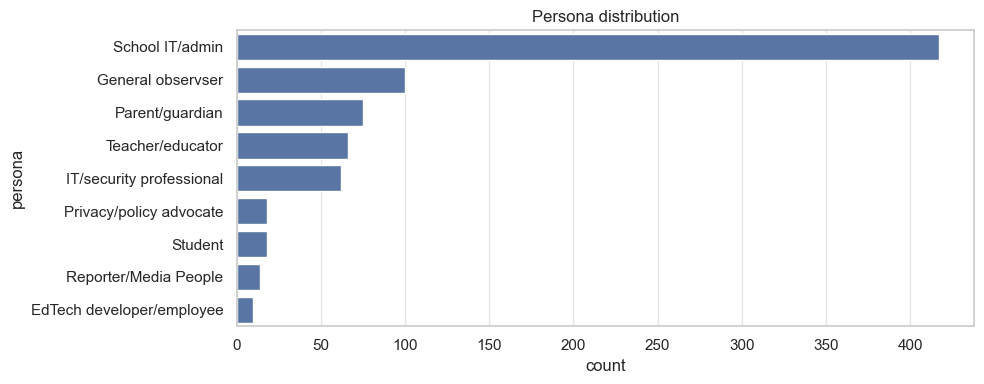

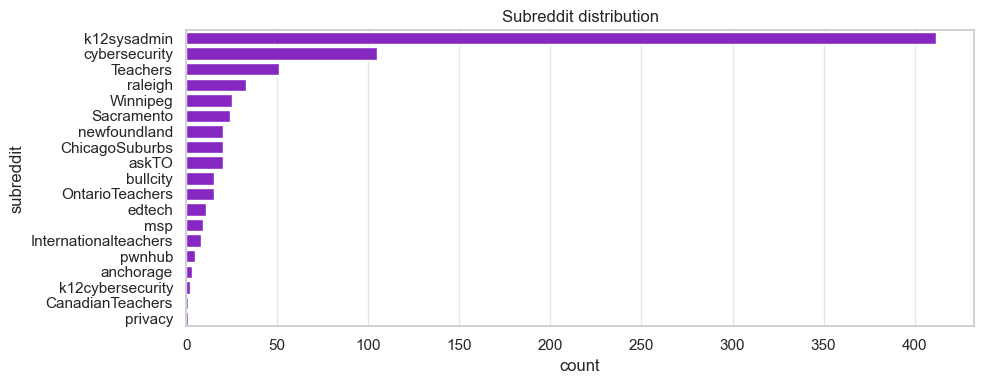

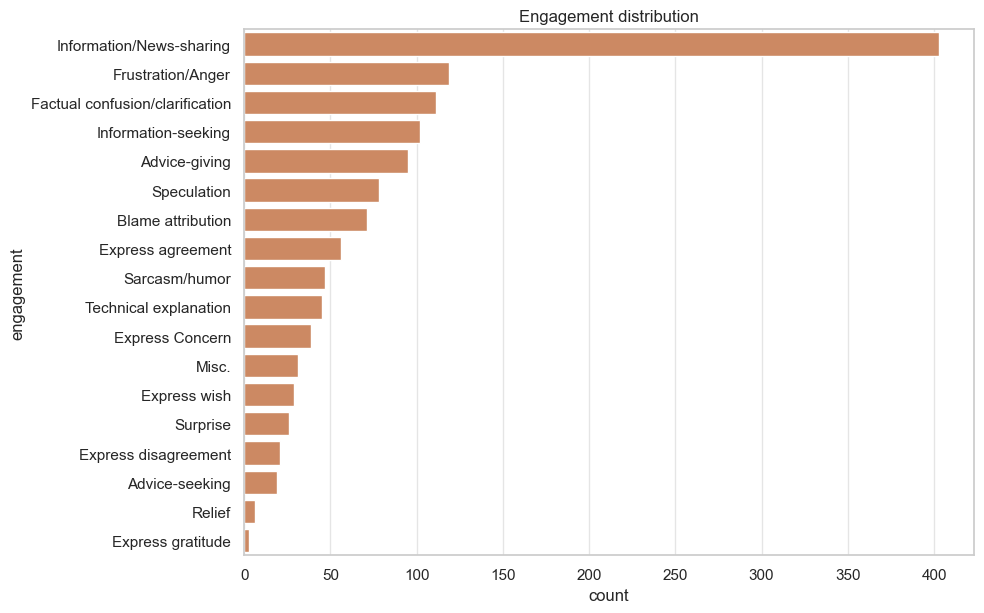

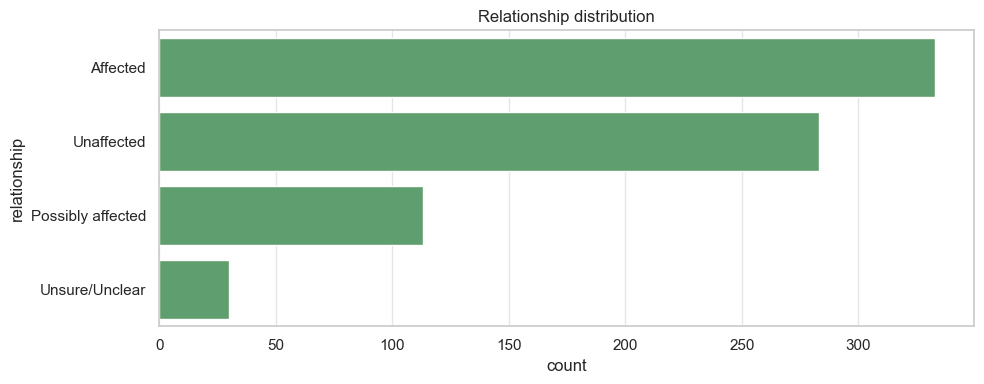

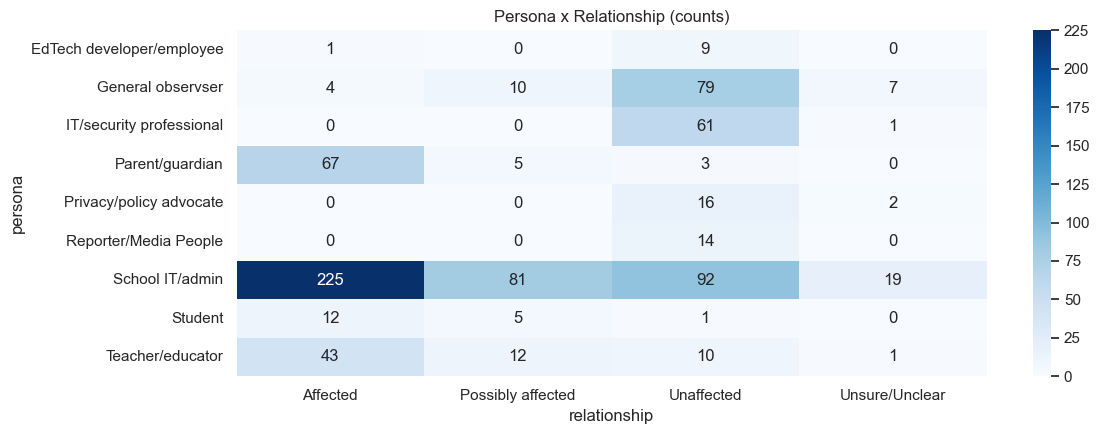

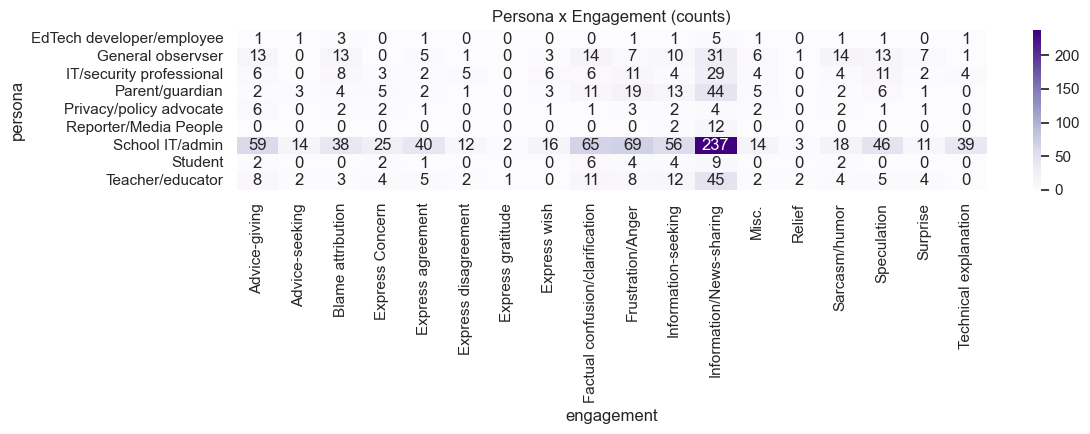

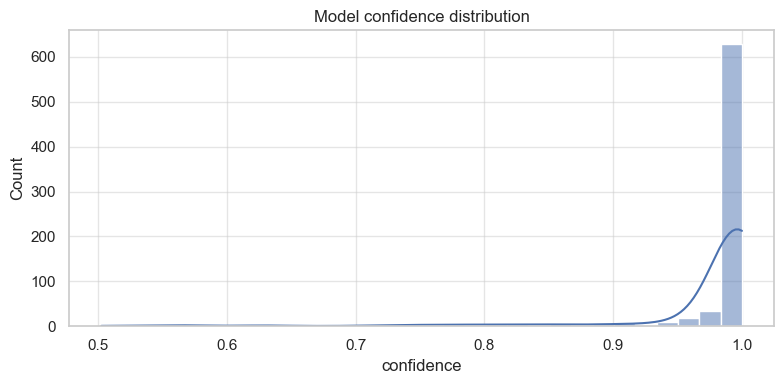

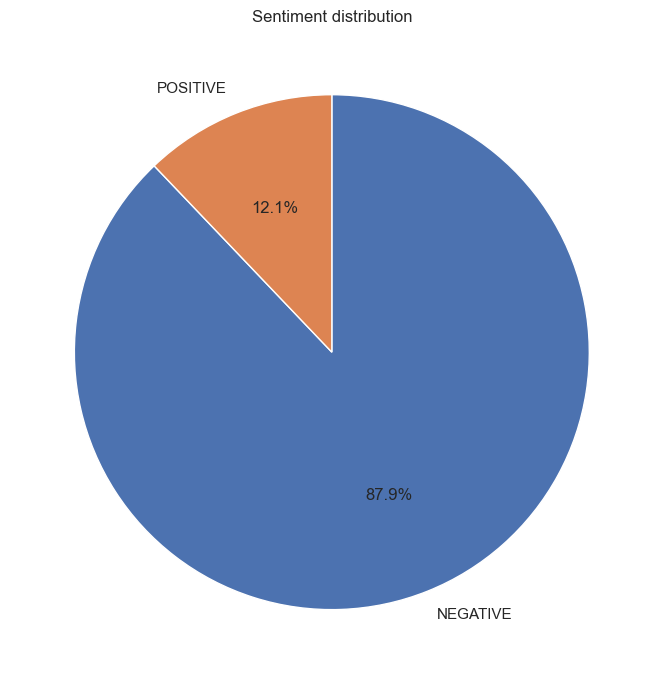

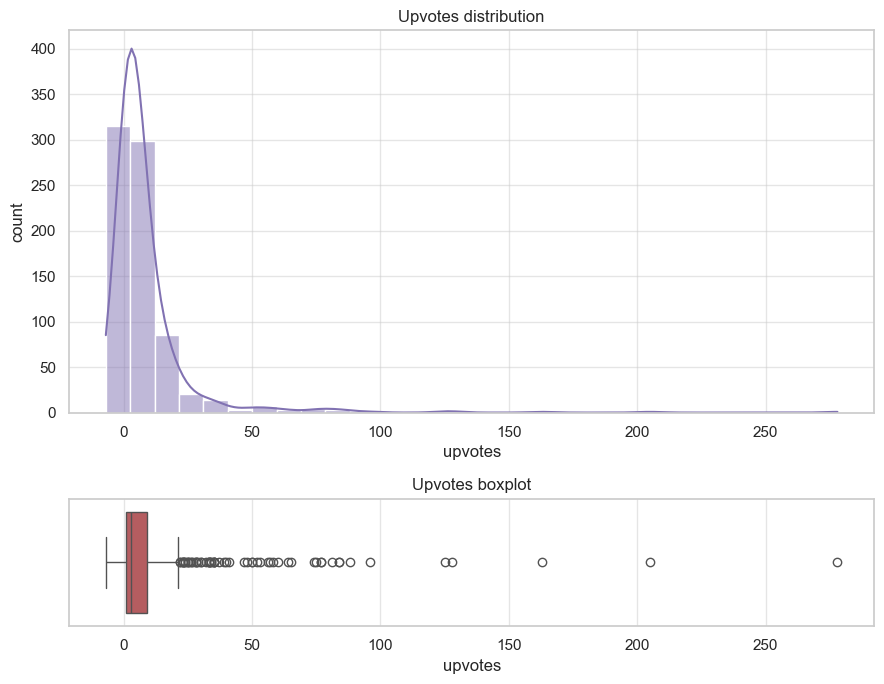

Saved plots:
- analysis_outputs\persona_distribution.png
- analysis_outputs\subreddit_distribution.png
- analysis_outputs\engagement_distribution.png
- analysis_outputs\relationship_distribution.png
- analysis_outputs\persona_relationship_heatmap.png
- analysis_outputs\persona_engagement_heatmap.png
- analysis_outputs\confidence_histogram.png
- analysis_outputs\sentiment_pie.png
- analysis_outputs\upvotes_distribution.png


In [17]:
# Plots (also saved to disk)
plots = []

# Persona distribution
if 'persona' in persona_analysis_df.columns:
    persona_dist = persona_analysis_df['persona'].fillna('(blank)').value_counts().reset_index()
    persona_dist.columns = ['persona', 'count']
    plt.figure(figsize=(10, max(4, 0.35 * len(persona_dist))))
    sns.barplot(data=persona_dist, y='persona', x='count', color='#4C72B0')
    plt.title('Persona distribution')
    plt.tight_layout()
    pfn = out_dir / 'persona_distribution.png'
    plt.savefig(pfn)
    display(plt.gcf())
    plt.close()
    plots.append(pfn)

# Subreddit distribution
if 'subreddit' in persona_analysis_df.columns:
    subreddit_dist = persona_analysis_df['subreddit'].fillna('(blank)').value_counts().reset_index()
    subreddit_dist.columns = ['subreddit', 'count']
    plt.figure(figsize=(10, max(4, 0.35 * len(persona_dist))))
    sns.barplot(data=subreddit_dist, y='subreddit', x='count', color='#8c0ddb')
    plt.title('Subreddit distribution')
    plt.tight_layout()
    pfn = out_dir / 'subreddit_distribution.png'
    plt.savefig(pfn)
    display(plt.gcf())
    plt.close()
    plots.append(pfn)

# Engagement distribution (supports comma-separated engagement labels)
if 'engagement' in engagement_analysis_df.columns:
    engagement_dist = engagement_analysis_df['engagement'].fillna('(blank)').value_counts().reset_index()
    engagement_dist.columns = ['engagement', 'count']
    plt.figure(figsize=(10, max(4, 0.35 * len(engagement_dist))))
    sns.barplot(data=engagement_dist, y='engagement', x='count', color='#DD8452')
    plt.title('Engagement distribution')
    plt.tight_layout()
    pfn = out_dir / 'engagement_distribution.png'
    plt.savefig(pfn)
    display(plt.gcf())
    plt.close()
    plots.append(pfn)

# Relationship distribution
if 'relationship' in df.columns:
    rel_dist = df['relationship'].fillna('(blank)').value_counts().reset_index()
    rel_dist.columns = ['relationship', 'count']
    plt.figure(figsize=(10, max(4, 0.35 * len(rel_dist))))
    sns.barplot(data=rel_dist, y='relationship', x='count', color='#55A868')
    plt.title('Relationship distribution')
    plt.tight_layout()
    pfn = out_dir / 'relationship_distribution.png'
    plt.savefig(pfn)
    display(plt.gcf())
    plt.close()
    plots.append(pfn)

# Heatmap persona x relationship
if ('persona' in persona_analysis_df.columns) and ('relationship' in persona_analysis_df.columns):
    ct = pd.crosstab(persona_analysis_df['persona'].fillna('(blank)'), persona_analysis_df['relationship'].fillna('(blank)'))
    plt.figure(figsize=(12, max(4, ct.shape[0]*0.5)))
    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
    plt.title('Persona x Relationship (counts)')
    plt.tight_layout()
    pfn = out_dir / 'persona_relationship_heatmap.png'
    plt.savefig(pfn)
    display(plt.gcf())
    plt.close()
    plots.append(pfn)

# Heatmap persona x engagement (supports comma-separated labels on both axes)
if ('persona' in persona_engagement_df.columns) and ('engagement' in persona_engagement_df.columns):
    ct_pe = pd.crosstab(persona_engagement_df['persona'], persona_engagement_df['engagement'])
    if not ct_pe.empty:
        plt.figure(figsize=(12, max(4, ct_pe.shape[0] * 0.5)))
        sns.heatmap(ct_pe, annot=True, fmt='d', cmap='Purples')
        plt.title('Persona x Engagement (counts)')
        plt.tight_layout()
        pfn = out_dir / 'persona_engagement_heatmap.png'
        plt.savefig(pfn)
        display(plt.gcf())
        plt.close()
        plots.append(pfn)

# Confidence distribution
if 'confidence' in df.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df['confidence'].dropna(), bins=30, kde=True)
    plt.title('Model confidence distribution')
    plt.tight_layout()
    pfn = out_dir / 'confidence_histogram.png'
    plt.savefig(pfn)
    display(plt.gcf())
    plt.close()
    plots.append(pfn)

#Sentiment pie chart
if 'sentiment' in df.columns:
    sentiment_counts = df['sentiment'].fillna('(blank)').astype(str).str.strip().replace('', '(blank)').value_counts()
    if not sentiment_counts.empty:
        plt.figure(figsize=(7, 7))
        plt.pie(
            sentiment_counts.values,
            labels=sentiment_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            counterclock=False
        )
        plt.title('Sentiment distribution')
        plt.tight_layout()
        pfn = out_dir / 'sentiment_pie.png'
        plt.savefig(pfn)
        display(plt.gcf())
        plt.close()
        plots.append(pfn)

# Upvotes distribution
if 'upvotes' in df.columns:
    up = pd.to_numeric(df['upvotes'], errors='coerce').dropna().reset_index(drop=True)
    if not up.empty:
        fig, axes = plt.subplots(2, 1, figsize=(9, 7), gridspec_kw={'height_ratios': [3, 1]})

        sns.histplot(up, bins=30, kde=True, ax=axes[0], color='#8172B2')
        axes[0].set_title('Upvotes distribution')
        axes[0].set_xlabel('upvotes')
        axes[0].set_ylabel('count')

        sns.boxplot(x=up, ax=axes[1], color='#C44E52')
        axes[1].set_xlabel('upvotes')
        axes[1].set_title('Upvotes boxplot')

        plt.tight_layout()
        pfn = out_dir / 'upvotes_distribution.png'
        plt.savefig(pfn)
        display(plt.gcf())
        plt.close()
        plots.append(pfn)

print('Saved plots:')
for p in plots:
    print('-', p)


In [7]:
# List saved output files
for p in sorted(Path('analysis_outputs').glob('*')):
    print(p.name)


author_persona_relationship_consistency.csv
confidence_histogram.png
engagement_counts.csv
irrelevant_summary.csv
persona_counts.csv
persona_distribution.png
persona_relationship_crosstab.csv
persona_relationship_heatmap.png
relationship_counts.csv
relationship_distribution.png
upvotes_vs_downvotes.png
